<a href="https://colab.research.google.com/github/hitesh-bhusara/machine-learning/blob/main/05_Foundation/01_insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('insurance.csv')

In [3]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


EDA

In [4]:
df.shape

(1338, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [8]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

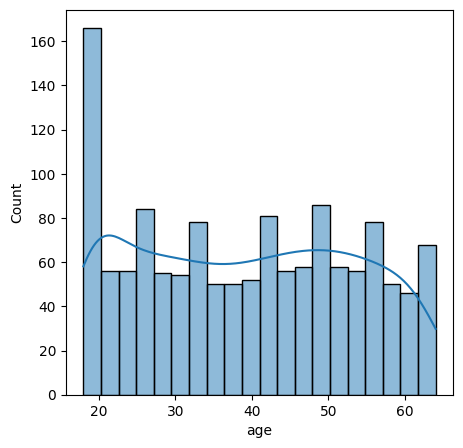

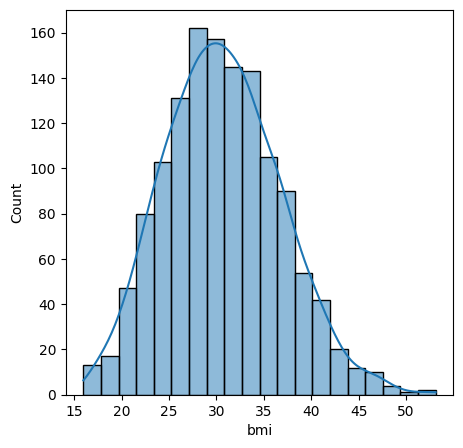

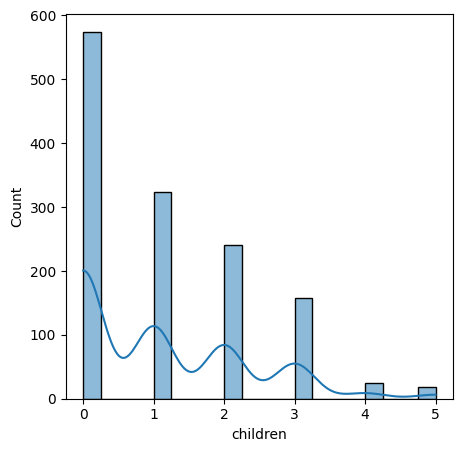

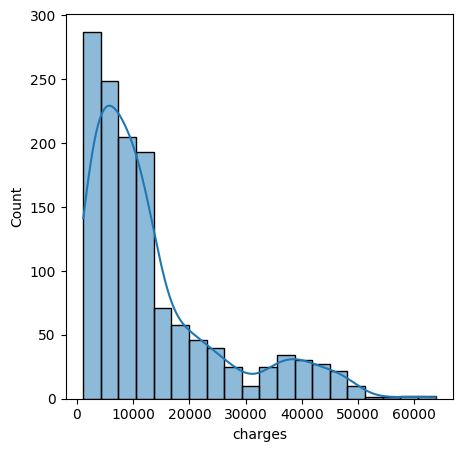

In [9]:
numeric_columns = ['age', 'bmi', 'children', 'charges']
for col in numeric_columns:
  plt.figure(figsize=(5,5))
  sns.histplot(df[col], kde=True,bins = 20)

<Axes: xlabel='children', ylabel='count'>

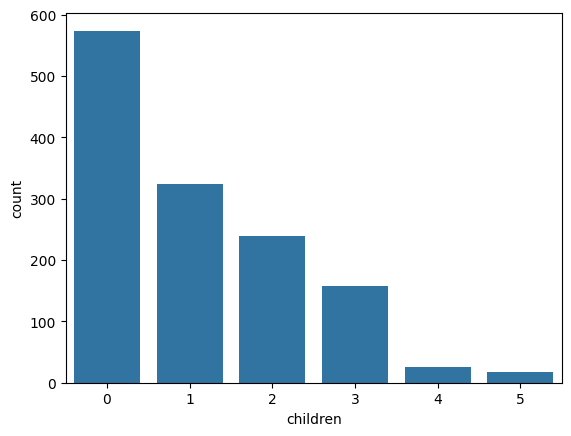

In [10]:
sns.countplot(x = df['children'])

<Axes: xlabel='sex', ylabel='count'>

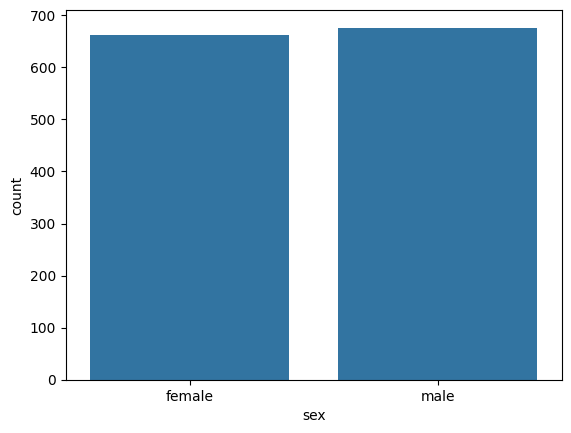

In [11]:
sns.countplot(x = df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

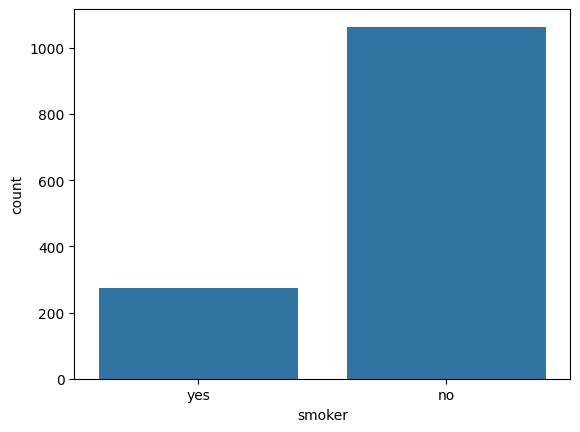

In [12]:
sns.countplot(x = df['smoker'])

for finding outliers

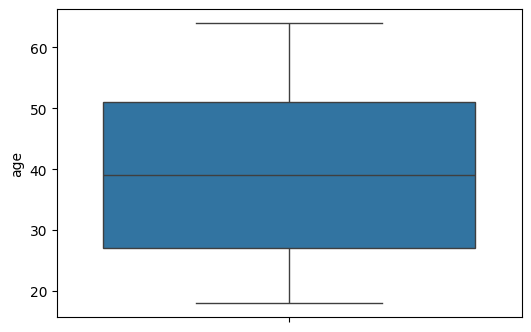

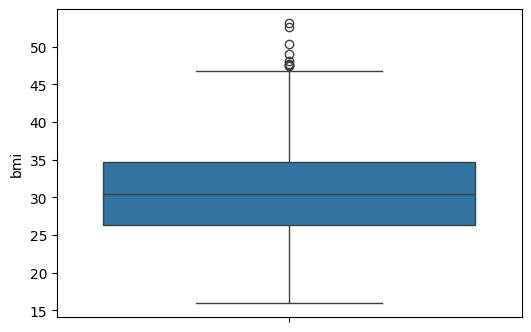

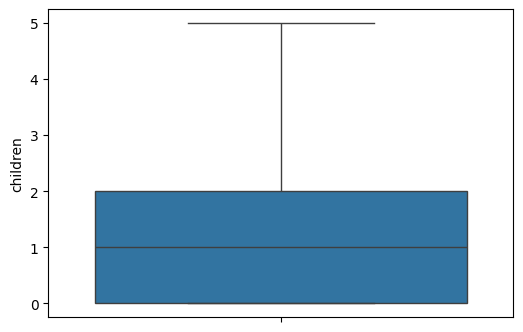

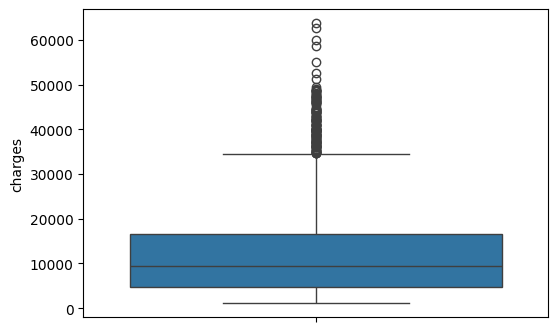

In [13]:
for col in numeric_columns:
  plt.figure(figsize=(6,4))
  sns.boxplot(df[col])

for correlation

<Axes: >

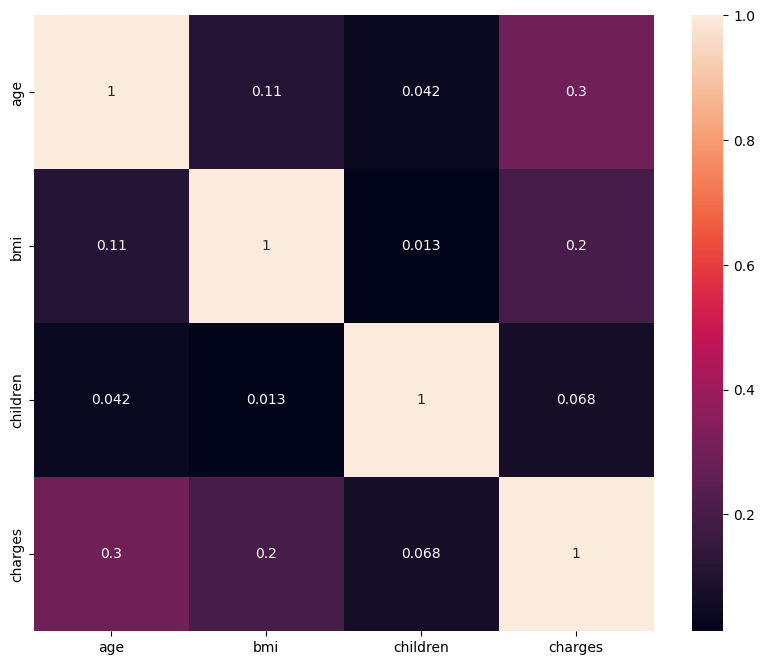

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)

Data Cleaning and preprocessing

In [15]:
df_cleaned = df.copy()

In [16]:
# remove null values-- we have 0 null values
df_cleaned.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [17]:
df_cleaned.shape

(1338, 7)

In [18]:
# remove duplicates
df_cleaned.drop_duplicates(inplace=True)

In [19]:
df_cleaned.shape

(1337, 7)

In [20]:
df_cleaned.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [21]:
# also to check if there are other word for same type
# like 'Male' , 'male' , 'M'
df_cleaned['sex'].value_counts()

,count
sex,
male,675
female,662


In [22]:
#  labled incoding for male and female
df_cleaned['sex'] = df_cleaned['sex'].map({'male':0,'female':1})

In [23]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [24]:
df_cleaned['smoker'].value_counts()

,count
smoker,
no,1063
yes,274


In [25]:
#  labled incoding for smoker
df_cleaned['smoker'] = df_cleaned['smoker'].map({'no':0,'yes':1})

In [26]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [27]:
df_cleaned.rename(columns={
    'sex':'is_female',
    'smoker':'is_smoker'
    },inplace=True)

In [28]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [29]:
df_cleaned['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


In [30]:
# one -hot incoding for region
df_cleaned = pd.get_dummies(df_cleaned,columns=['region'],drop_first=True)

In [31]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [32]:
df_cleaned = df_cleaned.astype(int)

In [33]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


Feature Engineering and Extraction

<Axes: xlabel='bmi', ylabel='Count'>

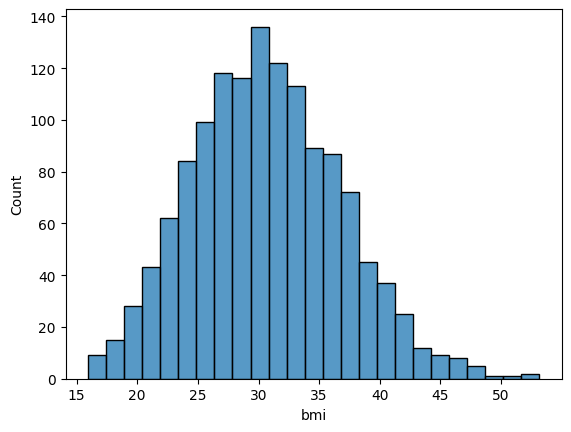

In [34]:
sns.histplot(df['bmi'])

In [35]:
# Underweight -   < 18.5
# Normal - 18.5 - 24.9
# Overweight -   25.0 - 29.9
# Obesity -   < 30.0

df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0,18.5,24.9,29.9,float('inf')],
    labels=['underweight','normal','overweight','obesity']
    )

In [36]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,overweight
1,18,0,33,1,0,1725,0,1,0,obesity
2,28,0,33,3,0,4449,0,1,0,obesity
3,33,0,22,0,0,21984,1,0,0,normal
4,32,0,28,0,0,3866,1,0,0,overweight


In [37]:
df_cleaned = pd.get_dummies(df_cleaned,columns=['bmi_category'],drop_first=True)

In [38]:
df_cleaned = df_cleaned.astype(int)

In [39]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obesity
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


Scaling

In [40]:
from sklearn.preprocessing import StandardScaler
cols = ['age','bmi','children']
scaler = StandardScaler()
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [42]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obesity
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


In [43]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_normal', 'bmi_category_overweight',
       'bmi_category_obesity'],
      dtype='object')

In [44]:
from scipy.stats import pearsonr
# pearson correlation calculation

# list of features to check against target
selected_features = ['age', 'is_female', 'bmi', 'children', 'is_smoker',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_normal', 'bmi_category_overweight',
       'bmi_category_obesity'
       ]

correlation = {
    feature: pearsonr(df_cleaned[feature],df_cleaned['charges'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(correlation.items(),columns=['Feature','Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation',ascending=False)

,Feature,Pearson Correlation
4,is_smoker,0.787234
0,age,0.298309
10,bmi_category_obesity,0.200348
2,bmi,0.196236
6,region_southeast,0.073577
3,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
1,is_female,-0.058046
8,bmi_category_normal,-0.104042


In [45]:
cat_feature = [
    'is_female','is_smoker','region_northwest',
    'region_southeast','region_southwest','bmi_category_normal',
    'bmi_category_overweight','bmi_category_obesity'
    ]

In [48]:
from scipy.stats import chi2_contingency

alpha = 0.05

df_cleaned['charges_bin'] = pd.cut(df_cleaned['charges'],bins=5,labels=False)
chi2_results = {}

for col in cat_feature:
  contingency_table = pd.crosstab(df_cleaned[col],df_cleaned['charges_bin'])
  chi2_stat,p_val,_,_ = chi2_contingency(contingency_table)
  decision = 'fail to reject null hypothesis(Drop Feature)'
  if p_val < alpha:
    decision = 'reject null hypothesis (Keep Feature)'
  chi2_results[col] = {
      'chi2_statistic':chi2_stat,
      'p_val':p_val,
      'decision':decision
  }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_val')
chi2_df

,chi2_statistic,p_val,decision
is_smoker,886.207228,0.0,reject null hypothesis (Keep Feature)
bmi_category_obesity,139.91117,0.0,reject null hypothesis (Keep Feature)
bmi_category_overweight,55.221078,0.0,reject null hypothesis (Keep Feature)
bmi_category_normal,43.03423,0.0,reject null hypothesis (Keep Feature)
region_southeast,13.796899,0.007972,reject null hypothesis (Keep Feature)
is_female,9.497799,0.049793,reject null hypothesis (Keep Feature)
region_southwest,6.632472,0.156633,fail to reject null hypothesis(Drop Feature)
region_northwest,3.568553,0.467532,fail to reject null hypothesis(Drop Feature)


In [49]:
final_df = df_cleaned[['age', 'is_female', 'bmi', 'children', 'is_smoker',
       'charges', 'region_southwest',
       'bmi_category_normal', 'bmi_category_overweight',
       'bmi_category_obesity']]

In [50]:
final_df

,age,is_female,bmi,children,is_smoker,charges,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obesity
0,-1.440418,1,-0.517949,-0.909234,1,16884,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,0,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,0,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,0,0,0,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,1,0,1,0
